In [1]:
# Imports
from functools import partial
import re
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import Aer, BasicAer
from qiskit.utils import QuantumInstance, algorithm_globals
from qiskit.algorithms.optimizers import SLSQP, COBYLA
from qiskit.algorithms.minimum_eigen_solvers import NumPyMinimumEigensolver, VQE
from qiskit.circuit.library import ExcitationPreserving

from qiskit_nature.problems.second_quantization import ElectronicStructureProblem
from qiskit_nature.converters.second_quantization import QubitConverter
from qiskit_nature.mappers.second_quantization import JordanWignerMapper, ParityMapper
from qiskit_nature.algorithms import GroundStateEigensolver
from qiskit_nature.drivers import UnitsType, Molecule
from qiskit_nature.drivers.second_quantization import ElectronicStructureDriverType, ElectronicStructureMoleculeDriver
from qiskit_nature.drivers.second_quantization import FCIDumpDriver

In [2]:
qubit_converter = QubitConverter(JordanWignerMapper(), two_qubit_reduction=True)
quantum_instance = QuantumInstance(backend=Aer.get_backend("aer_simulator_statevector"))

In [9]:
# Get a list of FCIDUMP files for SbH with different bond length
root = r"/home/ola/quantum_computing/RbH/opfermion/"
molecules = [(float(d)/100, root + d + "/FCIDUMP") for d in os.listdir(root) if re.match("\d\d\d", d)]
molecules.sort(key=lambda x: x[0])
molecules

[(1.8, '/home/ola/quantum_computing/RbH/opfermion/180/FCIDUMP'),
 (1.9, '/home/ola/quantum_computing/RbH/opfermion/190/FCIDUMP'),
 (2.0, '/home/ola/quantum_computing/RbH/opfermion/200/FCIDUMP'),
 (2.1, '/home/ola/quantum_computing/RbH/opfermion/210/FCIDUMP'),
 (2.2, '/home/ola/quantum_computing/RbH/opfermion/220/FCIDUMP'),
 (2.25, '/home/ola/quantum_computing/RbH/opfermion/225/FCIDUMP'),
 (2.3, '/home/ola/quantum_computing/RbH/opfermion/230/FCIDUMP'),
 (2.35, '/home/ola/quantum_computing/RbH/opfermion/235/FCIDUMP'),
 (2.4, '/home/ola/quantum_computing/RbH/opfermion/240/FCIDUMP'),
 (2.45, '/home/ola/quantum_computing/RbH/opfermion/245/FCIDUMP'),
 (2.5, '/home/ola/quantum_computing/RbH/opfermion/250/FCIDUMP'),
 (2.6, '/home/ola/quantum_computing/RbH/opfermion/260/FCIDUMP'),
 (2.7, '/home/ola/quantum_computing/RbH/opfermion/270/FCIDUMP'),
 (2.8, '/home/ola/quantum_computing/RbH/opfermion/280/FCIDUMP'),
 (2.9, '/home/ola/quantum_computing/RbH/opfermion/290/FCIDUMP'),
 (3.0, '/home/ola/quan

In [6]:
gs_solver_numpy = GroundStateEigensolver(qubit_converter, NumPyMinimumEigensolver())
driver = FCIDumpDriver('/home/ola/quantum_computing/RbH/opfermion/235/FCIDUMP', relativistic=True)
problem = ElectronicStructureProblem(driver=driver)
result = gs_solver_numpy.solve(problem)

We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	4 SOs
	1 alpha electrons
		orbital occupation: [1. 0.]
	1 beta electrons
		orbital occupation: [1. 0.]
num_alpha = 1
num_beta = 1


In [10]:
gs_solver_numpy = GroundStateEigensolver(qubit_converter, NumPyMinimumEigensolver())

point_exact = []
energy_exact = []
vector_exact = []

for bond_length, fcidump in molecules:
    driver = FCIDumpDriver(fcidump, relativistic=True)
    problem = ElectronicStructureProblem(driver=driver)
    result = gs_solver_numpy.solve(problem)
    print(result)
    point_exact.append(bond_length)
    energy_exact.append(result.total_energies[0])
    print("RESULT", point_exact, energy_exact)

We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	4 SOs
	1 alpha electrons
		orbital occupation: [1. 0.]
	1 beta electrons
		orbital occupation: [1. 0.]
num_alpha = 1
num_beta = 1
=== GROUND STATE ENERGY ===
 
* Electronic ground state energy (Hartree): -0.90902171511
  - computed part:      -0.90902171511
~ Nuclear repulsion energy (Hartree): -2979.411715975853
> Total ground state energy (Hartree): -2980.320737690963
RESULT [1.8] [(-2980.3207376909627+0j)]
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	4 SOs
	1 alpha electrons
		orbital occupation: [1. 0.]
	1 beta electrons
		orbital occupation: [1. 0.]
num_alpha = 1
num_beta = 1
=== GROUND STATE ENERGY ===
 
* Electronic ground state energy (Hartree): -0.919436284898
  - computed part:      -0.919436284898
~ Nuclear repulsion energy (Hartree): -2979.416512490788
> Total ground state energ

Text(0.5, 1.0, 'Jordan-Wigner Mapper, NumpyEigenSolver')

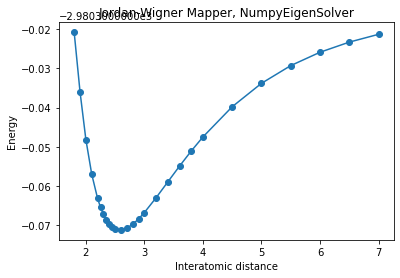

In [11]:
plt.plot(point_exact, energy_exact, marker="o")
plt.title("Dissociation profile")
plt.xlabel("Interatomic distance")
plt.ylabel("Energy")
plt.title('Jordan-Wigner Mapper, NumpyEigenSolver')

In [13]:
solver_vqe = VQE(quantum_instance=quantum_instance)
gs_solver_vqe = GroundStateEigensolver(qubit_converter, solver_vqe)

point_vqe = []
energy_vqe = []
results_vqe = []

for bond_length, fcidump in molecules:
    driver = FCIDumpDriver(fcidump, relativistic=True)
    problem = ElectronicStructureProblem(driver=driver)
    # Solve problem a few times, choose the best solution (lowest energy)
    vqe_1 = gs_solver_vqe.solve(problem)
    result_vqe = vqe_1
    other_results = []
    for i in range(10):
        solver_vqe.initial_point = np.random.rand(*result_vqe.raw_result.optimal_point.shape)
        vqe_2 = gs_solver_vqe.solve(problem)
        other_results.append(vqe_2)
    result_vqe = min(vqe_1, *other_results, key=lambda x: x.total_energies[0])
    # Choose the lowest energy solution
    point_vqe.append(bond_length)
    energy_vqe.append(result_vqe.total_energies[0])
    solver_vqe.initial_point = result_vqe.raw_result.optimal_point

We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	4 SOs
	1 alpha electrons
		orbital occupation: [1. 0.]
	1 beta electrons
		orbital occupation: [1. 0.]
num_alpha = 1
num_beta = 1
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	4 SOs
	1 alpha electrons
		orbital occupation: [1. 0.]
	1 beta electrons
		orbital occupation: [1. 0.]
num_alpha = 1
num_beta = 1
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	4 SOs
	1 alpha electrons
		orbital occupation: [1. 0.]
	1 beta electrons
		orbital occupation: [1. 0.]
num_alpha = 1
num_beta = 1
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	4 SOs
	1 alpha electrons
		orbital occupation: [1. 0.]
	1 beta electrons
		orbital occupation: [1. 0.]
num_alpha = 1
num_b

/home/ola/miniconda3/envs/qiskit037/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 1.0, 'Jordan-Wigner Mapper, VQE')

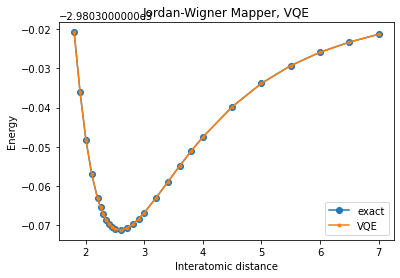

In [14]:
plt.plot(point_exact, energy_exact, marker="o", label="exact")
plt.plot(point_vqe, energy_vqe, marker=".", label="VQE")
plt.title("Dissociation profile")
plt.xlabel("Interatomic distance")
plt.ylabel("Energy")
plt.legend()
plt.title('Jordan-Wigner Mapper, VQE')